# 03 — Resonator Spectroscopy

## Purpose

Determine the resonator center frequency and linewidth (κ) by sweeping the readout drive frequency. This is the first frequency-domain characterization experiment after verifying the ADC timing.

## Methodology

1. **1D frequency sweep** — drive the readout resonator across a configurable bandwidth centered on the current runtime readout frequency, averaging over `n_avg` repetitions
2. **Lorentzian fit** — extract the resonator center frequency (f₀) and linewidth (κ) from the magnitude response
3. **Optional calibration commit** — if `APPLY_RESONATOR_FREQUENCY_CALIBRATION = True`, update the runtime LO/IF assignments to center on the fitted f₀

## Expected Outcomes

- A clear dip (or peak, depending on coupling) in the magnitude spectrum at the resonator frequency
- Fitted f₀ within a few MHz of the runtime `attr.ro_fq` value
- Fitted κ consistent with the expected resonator linewidth (typically 0.5–5 MHz for 3D cavities)
- Phase trace showing a characteristic ~360° wrap through the resonance

## Prerequisites

- **Notebook 00** — hardware session established
- **Notebook 01** — mixer calibration complete
- **Notebook 02** — time-of-flight timing verified

## 1. Setup — Session Bootstrap

Open the notebook stage and load the prior time-of-flight checkpoint. The session is reopened cleanly to ensure a fresh QM connection.

In [6]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from qualang_tools.units import unit

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "qubox").exists():
    REPO_ROOT = Path(r"E:\qubox")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from qubox.notebook import (
    ResonatorSpectroscopy,
    load_stage_checkpoint,
    open_notebook_stage,
    preview_or_apply_patch_ops,
    save_stage_checkpoint,
)

REGISTRY_BASE = Path(r"E:\qubox")
SAMPLE_ID = "post_cavity_sample_A"
COOLDOWN_ID = "cd_2026_03_24"
QOP_IP = "10.157.36.68"
CLUSTER_NAME = "Cluster_2"

stage = open_notebook_stage(
    stage_name="03_resonator_spectroscopy",
    registry_base=REGISTRY_BASE,
    sample_id=SAMPLE_ID,
    cooldown_id=COOLDOWN_ID,
    qop_ip=QOP_IP,
    cluster_name=CLUSTER_NAME,
    force_reopen=True,
    close_existing=True,
)
session = stage.session
attr = stage.attr
SESSION_BOOTSTRAP_PATH = stage.bootstrap_path
u = unit(coerce_to_integer=True)

time_of_flight_checkpoint = load_stage_checkpoint(
    registry_base=REGISTRY_BASE,
    sample_id=SAMPLE_ID,
    cooldown_id=COOLDOWN_ID,
    stage_name="02_time_of_flight",
)

print(f"Repo root on sys.path: {REPO_ROOT}")
print(f"Shared session bootstrap: {SESSION_BOOTSTRAP_PATH}")
print(f"Stage checkpoint path: {stage.checkpoint_path}")
print(f"Closed a live in-memory session before reopen: {stage.had_live_session}")
print(f"QM endpoint: {QOP_IP} ({CLUSTER_NAME})")
print(f"Current readout frequency: {float(attr.ro_fq) / 1e9:.6f} GHz")
if time_of_flight_checkpoint is not None:
    print(
        "Prior stage 02 status: "
        f"{time_of_flight_checkpoint['status']}"
        f" ({time_of_flight_checkpoint['summary']})"
    )

2026-03-24 01:52:54,826 - qm - INFO     - Performing health check
2026-03-24 01:52:54,830 - qm - INFO     - Health check passed


e:\qubox\.venv\Lib\site-packages\qm\program\_qua_config_schema.py:1877: DeprecationWarning: 'version' is deprecated since "1.2.2" and will be removed in "2.0.0". Please remove it from the Qua config.
  warnings.warn(


Repo root on sys.path: E:\qubox
Shared session bootstrap: E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2026_03_24\artifacts\runtime\notebook_session.json
Stage checkpoint path: E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2026_03_24\artifacts\runtime\notebook_stage_03_resonator_spectroscopy.json
Closed a live in-memory session before reopen: True
QM endpoint: 10.157.36.68 (Cluster_2)
Current readout frequency: 8.596223 GHz


## 2. Configuration — Spectroscopy Parameters

Define the frequency sweep range, step size, and averaging count. The sweep window is centered on the current runtime readout frequency and spans ±10 MHz by default.

In [2]:
APPLY_RESONATOR_FREQUENCY_CALIBRATION = False

RESONATOR_SPEC_READOUT_OP = "readout"
RESONATOR_SPEC_CENTER_HZ = float(getattr(attr, "ro_fq", 0.0))
RESONATOR_SPEC_SPAN_HZ = 20 * u.MHz
RESONATOR_SPEC_RF_BEGIN = int(RESONATOR_SPEC_CENTER_HZ - RESONATOR_SPEC_SPAN_HZ / 2)
RESONATOR_SPEC_RF_END = int(RESONATOR_SPEC_CENTER_HZ + RESONATOR_SPEC_SPAN_HZ / 2)
RESONATOR_SPEC_DF = 500 * u.kHz
RESONATOR_SPEC_N_AVG = 2000
RESONATOR_SPEC_RO_THERM_CLKS = int(getattr(attr, "ro_therm_clks", 1000) or 1000)

print("Resonator spectroscopy stage settings:")
print(f"  apply resonator-frequency calibration: {APPLY_RESONATOR_FREQUENCY_CALIBRATION}")
print(f"  readout op: {RESONATOR_SPEC_READOUT_OP}")
print(f"  center: {RESONATOR_SPEC_CENTER_HZ / 1e9:.6f} GHz")
print(f"  rf window: {RESONATOR_SPEC_RF_BEGIN / 1e9:.6f} -> {RESONATOR_SPEC_RF_END / 1e9:.6f} GHz")
print(f"  df: {RESONATOR_SPEC_DF / 1e3:.1f} kHz")
print(f"  n_avg: {RESONATOR_SPEC_N_AVG}")
print(f"  ro_therm_clks: {RESONATOR_SPEC_RO_THERM_CLKS}")

Resonator spectroscopy stage settings:
  apply resonator-frequency calibration: False
  readout op: readout
  center: 8.596223 GHz
  rf window: 8.586223 -> 8.606223 GHz
  df: 500.0 kHz
  n_avg: 2000
  ro_therm_clks: 1000


## 3. Execution — Run Spectroscopy, Fit, and Save Checkpoint

Run the frequency sweep, fit the resonator response, optionally apply the frequency calibration, and save the stage checkpoint for downstream notebooks.

2026-03-24 01:52:12,716 - qm - INFO     - Sending program to QOP for compilation
2026-03-24 01:52:12,781 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 1999/2000 [00:00<00:00, 3570.57it/s]


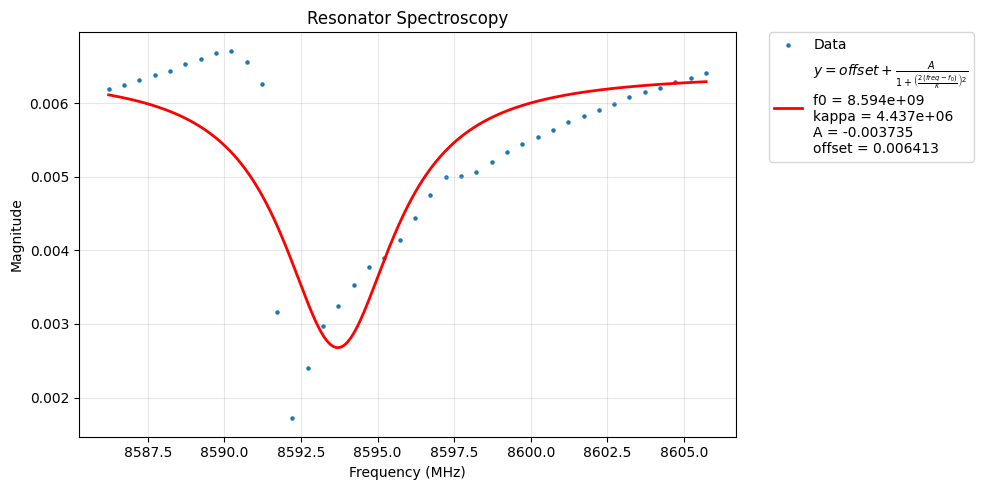

Resonator spectroscopy frequency calibration patch preview (2 updates):
  1. SetCalibration: {'path': 'cqed_params.resonator.lo_freq', 'value': 8800000000.0}
  2. SetCalibration: {'path': 'cqed_params.resonator.if_freq', 'value': -206299783.41876602}
Patch not applied. Enable the stage apply flag to commit the calibration.
Fitted f0: 8.593700 GHz
Fitted kappa: 4.437270 MHz
Runtime attr.ro_fq delta: -2.522 MHz
Stage checkpoint saved to: E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2026_03_24\artifacts\runtime\notebook_stage_03_resonator_spectroscopy.json


In [3]:
resonator_spec = ResonatorSpectroscopy(session)
resonator_result = resonator_spec.run(
    readout_op=RESONATOR_SPEC_READOUT_OP,
    rf_begin=RESONATOR_SPEC_RF_BEGIN,
    rf_end=RESONATOR_SPEC_RF_END,
    df=RESONATOR_SPEC_DF,
    n_avg=RESONATOR_SPEC_N_AVG,
    ro_therm_clks=RESONATOR_SPEC_RO_THERM_CLKS,
)
resonator_analysis = resonator_spec.analyze(resonator_result, update_calibration=True)
resonator_spec.plot(resonator_analysis)

resonator_patch, resonator_patch_preview, resonator_apply_result = preview_or_apply_patch_ops(
    session,
    reason="Resonator spectroscopy frequency calibration",
    proposed_patch_ops=resonator_analysis.metadata.get("proposed_patch_ops", []),
    apply=APPLY_RESONATOR_FREQUENCY_CALIBRATION,
)

if resonator_apply_result is not None:
    context_snapshot = getattr(session, "context_snapshot", None)
    attr = context_snapshot() if callable(context_snapshot) else getattr(session, "attributes", None)
    if attr is None:
        raise RuntimeError("Calibration applied, but the refreshed cQED attribute snapshot is unavailable.")

fitted_f0_hz = float(resonator_analysis.metrics.get("f0", np.nan))
fitted_kappa_hz = float(resonator_analysis.metrics.get("kappa", np.nan))

stage_checkpoint_path = save_stage_checkpoint(
    registry_base=REGISTRY_BASE,
    sample_id=SAMPLE_ID,
    cooldown_id=COOLDOWN_ID,
    stage_name="03_resonator_spectroscopy",
    status="calibrated" if resonator_apply_result is not None else "characterized",
    summary="Measured resonator center frequency and optionally committed the LO/IF update.",
    consumed_inputs={
        "readout_op": RESONATOR_SPEC_READOUT_OP,
        "rf_begin_hz": RESONATOR_SPEC_RF_BEGIN,
        "rf_end_hz": RESONATOR_SPEC_RF_END,
        "df_hz": RESONATOR_SPEC_DF,
        "n_avg": RESONATOR_SPEC_N_AVG,
    },
    persisted_outputs={
        "applied": resonator_apply_result is not None,
        "proposed_patch_ops": resonator_analysis.metadata.get("proposed_patch_ops", []),
        "runtime_ro_fq_hz": float(attr.ro_fq),
    },
    advisory_outputs={
        "fitted_f0_hz": fitted_f0_hz,
        "fitted_kappa_hz": fitted_kappa_hz,
    },
    next_stage="04_resonator_power_chevron",
    notes=[
        "Stage 04 may assume this fitted center as the frequency window midpoint.",
        "A missing apply means the chevron remains a characterization pass around the current runtime readout frequency.",
    ],
    metrics=dict(resonator_analysis.metrics),
)

print(f"Fitted f0: {fitted_f0_hz / 1e9:.6f} GHz")
print(f"Fitted kappa: {fitted_kappa_hz / 1e6:.6f} MHz")
print(f"Runtime attr.ro_fq delta: {(fitted_f0_hz - float(attr.ro_fq)) / 1e6:+.3f} MHz")
print(f"Stage checkpoint saved to: {stage_checkpoint_path}")

## 4. Analysis — Magnitude and Phase Plots

Detailed magnitude and phase traces of the resonator sweep with markers at the runtime frequency and the fitted center frequency. Use these plots to visually confirm the fit quality before moving on to the power chevron.

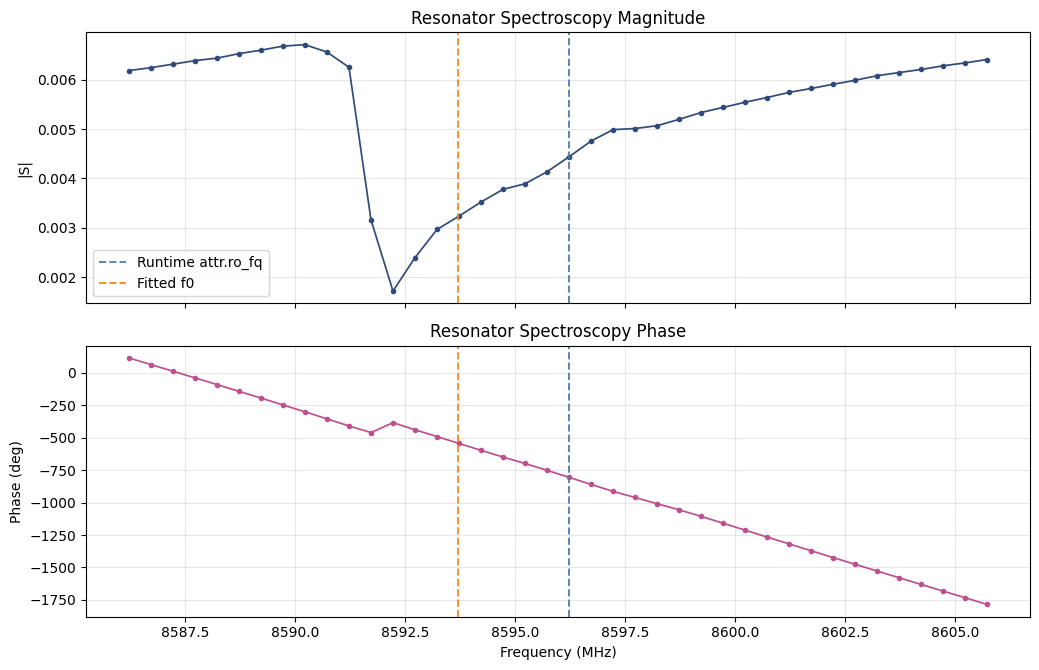

Fitted linewidth kappa: 4.437270 MHz
Fitted center frequency: 8.593700 GHz
Runtime delta: -2.522 MHz


In [4]:
if "resonator_analysis" not in globals():
    print("Run the spectroscopy cell above to generate the magnitude and phase plots.")
else:
    frequencies_hz = np.asarray(resonator_analysis.data.get("frequencies", []), dtype=float)
    S = np.asarray(resonator_analysis.data.get("S", []))
    magnitude = np.asarray(resonator_analysis.data.get("magnitude", np.abs(S)), dtype=float)
    if frequencies_hz.size == 0 or S.size == 0:
        raise RuntimeError("Resonator spectroscopy analysis did not expose frequencies/S for plotting.")

    phase_deg = np.unwrap(np.angle(S)) * 180.0 / np.pi
    fitted_f0_hz = float(resonator_analysis.metrics.get("f0", np.nan))
    fitted_kappa_hz = float(resonator_analysis.metrics.get("kappa", np.nan))

    marker_rows = [
        ("Runtime attr.ro_fq", float(attr.ro_fq), "#4c78a8"),
        ("Fitted f0", fitted_f0_hz, "#f58518"),
    ]

    fig, axes = plt.subplots(2, 1, figsize=(10.5, 6.8), sharex=True)
    freq_mhz = frequencies_hz / 1e6

    axes[0].plot(freq_mhz, magnitude, marker="o", ms=3, lw=1.25, color="#2f4b7c")
    axes[0].set_ylabel("|S|")
    axes[0].set_title("Resonator Spectroscopy Magnitude")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(freq_mhz, phase_deg, marker="o", ms=3, lw=1.25, color="#bc5090")
    axes[1].set_xlabel("Frequency (MHz)")
    axes[1].set_ylabel("Phase (deg)")
    axes[1].set_title("Resonator Spectroscopy Phase")
    axes[1].grid(True, alpha=0.3)

    for label, frequency_hz, color in marker_rows:
        if np.isfinite(frequency_hz):
            for ax in axes:
                ax.axvline(frequency_hz / 1e6, color=color, ls="--", lw=1.4, alpha=0.9, label=label)

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        axes[0].legend(handles[: len(marker_rows)], labels[: len(marker_rows)], loc="best")

    plt.tight_layout()
    plt.show()

    if np.isfinite(fitted_kappa_hz):
        print(f"Fitted linewidth kappa: {fitted_kappa_hz / 1e6:.6f} MHz")
    print(f"Fitted center frequency: {fitted_f0_hz / 1e9:.6f} GHz")
    print(f"Runtime delta: {(fitted_f0_hz - float(attr.ro_fq)) / 1e6:+.3f} MHz")

In [5]:
if "resonator_analysis" not in globals():
    print("Suggested next step after running this notebook: use the fitted f0 to center notebook 04's power chevron window.")
else:
    fitted_f0_hz = float(resonator_analysis.metrics.get("f0", np.nan))
    next_begin_hz = fitted_f0_hz - 10e6
    next_end_hz = fitted_f0_hz + 10e6
    print("Suggested notebook 04 power-chevron window:")
    print(f"  rf_begin = {next_begin_hz / 1e9:.6f} GHz")
    print(f"  rf_end   = {next_end_hz / 1e9:.6f} GHz")
    print(f"  center   = {fitted_f0_hz / 1e9:.6f} GHz")

Suggested notebook 04 power-chevron window:
  rf_begin = 8.583700 GHz
  rf_end   = 8.603700 GHz
  center   = 8.593700 GHz
